1. Познакомьтесь с данными.
2. Осуществите предобработку данных.
    - 2.1 Приведите заголовки к удобному виду.
    - 2.2 Проверьте типы данных.
    - 2.3 Обработайте пропуски.
    - 2.4 Проверьте наличие дубликатов.
    - 2.5 Исключите нулевые значения в выручке для дальнейшего исследования. 
3. Исследовательский анализ данных:
     - 3.1 Создайте отчет о динамике продаж (выручке). Постройте линейный график. Повторите отчет с детализацией по полям: FFP_FLAG, ROUTE_FLIGHT_TYPE, SALE_TYPE. Постройте общие отчеты по выручке по типам пассажиров, по типам перелета, по способам покупки, по программам лояльности. Визуализируйте каждый отчет. Решение о детализации отчетов примите самостоятельно.
     - 3.2 Исследуйте выручку, примите решение об исключении выбросов для дальнейшего исследования, руководствуясь минимизацией потерь в данных.
     - 3.3 Исследуйте сезонность продаж. Дополнительно проверьте гипотезу о том, что выручка от продаж осенью и зимой отличается. Исследуйте выручку и число продаж по месяцам, проверьте корреляцию.
     - 3.4 Клиенты покупают билеты в разное время. Кто-то покупает билеты заранее, другие - в последний момент. Проверьте гипотезу о том, что выручка от продажи билетов для этих двух групп клиентов отличается. Предварительно разбейте клиентов минимум на три группы.
     - 3 .5  Определите топ-10 популярных направлений перелета (город-город) отдельно для ВМЛ и МВЛ. Изучите выручку для этих направлений. Для этого добавьте в датасет сведения о городах, используя данные из датасета:
     https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat
     - 3.6 Определите есть ли зависимость выручки от других признаков. Постройте матрицу корреляций.

Каждый пункт исследования сопроводите выводами.


In [164]:
# импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import t, norm
from scipy import stats as st

In [165]:
air_data = pd.read_csv('air_data.csv', sep=';')    #загружаем данные, знакомимся с содержанием файла
air_data.head(5)

,ISSUE_DATE,FLIGHT_DATE_LOC,PAX_TYPE,REVENUE_AMOUNT,ORIG_CITY_CODE,DEST_CITY_CODE,ROUTE_FLIGHT_TYPE,FFP_FLAG,SALE_TYPE
0,2021-12-07 00:00:00,2022-01-11 00:00:00,AD,200,MOW,KGD,ВВЛ,NaN,ONLINE
1,2021-12-31 00:00:00,2022-01-03 00:00:00,AD,610,UUS,OVB,ВВЛ,NaN,OFFLINE
2,2021-11-28 00:00:00,2022-01-04 00:00:00,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE
3,2021-12-08 00:00:00,2022-01-05 00:00:00,AD,190,VOZ,MOW,ВВЛ,NaN,ONLINE
4,2021-12-08 00:00:00,2022-01-12 00:00:00,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE


# *<span style="color:#87CEEB">Предобработка данных</span>*

In [166]:
air_data.columns = air_data.columns.str.lower()    #2.1 названия столбцов корректные, 
#однако не рекомендуется использовать заглавные буквы в наименованиях, приведем заголовки к нижнему регистру

In [167]:
air_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   issue_date         50000 non-null  object
 1   flight_date_loc    50000 non-null  object
 2   pax_type           50000 non-null  object
 3   revenue_amount     50000 non-null  int64 
 4   orig_city_code     49998 non-null  object
 5   dest_city_code     49999 non-null  object
 6   route_flight_type  50000 non-null  object
 7   ffp_flag           19398 non-null  object
 8   sale_type          50000 non-null  object
dtypes: int64(1), object(8)
memory usage: 3.4+ MB


<span style="color:#000000">**issue_date** и **flight_date_loc** имеют тип данных object и должны быть преобразованы в формат дата и время, тип остальных столбцов корректен</span>

In [168]:
air_data['issue_date'] = pd.to_datetime(air_data['issue_date'], format='%Y-%m-%d %H:%M:%S')    #преобразуем
air_data['flight_date_loc'] = pd.to_datetime(air_data['flight_date_loc'], format='%Y-%m-%d %H:%M:%S')

In [169]:
air_data.info()    #проверяем преобразования, все в порядке

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   issue_date         50000 non-null  datetime64[ns]
 1   flight_date_loc    50000 non-null  datetime64[ns]
 2   pax_type           50000 non-null  object        
 3   revenue_amount     50000 non-null  int64         
 4   orig_city_code     49998 non-null  object        
 5   dest_city_code     49999 non-null  object        
 6   route_flight_type  50000 non-null  object        
 7   ffp_flag           19398 non-null  object        
 8   sale_type          50000 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(6)
memory usage: 3.4+ MB


In [170]:
air_data['year'] = air_data['issue_date'].dt.year    #добавляем столбец с годом и месяцем для дальнейшего анализа
air_data['month'] = air_data['issue_date'].dt.month
air_data['day'] = air_data['issue_date'].dt.day

### *<span style="color:#FFB6C1">2.3 Обработка пропусков</span>*

Отсутствующие значения присутствуют только в трех столбцах: **orig_city_code**, **dest_city_code** и **ffp_flag**. Остальные переменные не содержат пропусков.

In [171]:
air_data[air_data['orig_city_code'].isna()]    #обработаем orig_city_code

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year,month,day
2020,2022-02-17,2022-03-22,AD,440,NaN,KHV,МВЛ,NaN,ONLINE,2022,2,17
8100,2022-05-02,2022-05-11,AD,440,NaN,KHV,МВЛ,NaN,OFFLINE,2022,5,2


In [172]:
air_data[air_data['dest_city_code'] == 'KHV']['orig_city_code'].value_counts()    #самые частые маршруты в KHV

orig_city_code
OVB    268
VVO     38
IKT     36
UUS     36
PKC     14
YKS      9
BKK      4
BQS      3
HTA      2
UUD      2
OHH      1
NER      1
Name: count, dtype: int64

In [173]:
air_data[air_data['dest_city_code'].isna()]    #понаблюдаем за dest_city_code

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year,month,day
47582,2022-05-13,2022-07-28,AD,440,KHV,NaN,МВЛ,NaN,OFFLINE,2022,5,13


In [174]:
air_data[air_data['orig_city_code'] == 'KHV']['dest_city_code'].value_counts()    #самые частые маршруты из KHV

dest_city_code
OVB    240
UUS     55
VVO     43
IKT     29
PKC      9
YKS      8
BQS      3
BKK      3
HTA      2
NGK      1
Name: count, dtype: int64

Аэропорт KHV является как пунктом прибытия для рейсов из множества городов, так и пунктом отправления в различные направления, что делает однозначное восстановление пропущенных значений невозможным. Попробуем восстановить пропуски, обращаясь к дополнительной базе данных.

In [175]:
column_names = ['airport_name', 'location', 'country', 'iata_code', 'icao_code', 'latitude', 'longitude', 'altitude', 'timezone', 'dst', 'timezone_region', 'type', 'source']

In [176]:
code = pd.read_csv('airports.dat.csv', sep=',', header=None, names=column_names)
code.head(5)
#исходный файл не содержит заголовков, при загрузке данных это учтено (header=None + указание названий столбцов через параметр names)

,airport_name,location,country,iata_code,icao_code,latitude,longitude,altitude,timezone,dst,timezone_region,type,source
1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports
2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10,U,Pacific/Port_Moresby,airport,OurAirports
3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10,U,Pacific/Port_Moresby,airport,OurAirports
4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10,U,Pacific/Port_Moresby,airport,OurAirports
5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10,U,Pacific/Port_Moresby,airport,OurAirports


In [177]:
code[code['iata_code'] == 'KHV']

,airport_name,location,country,iata_code,icao_code,latitude,longitude,altitude,timezone,dst,timezone_region,type,source
2927,Khabarovsk-Novy Airport,Khabarovsk,Russia,KHV,UHHH,48.528,135.188004,244,10,N,Asia/Vladivostok,airport,OurAirports


In [178]:
code[code['icao_code'] == 'KHV']

,airport_name,location,country,iata_code,icao_code,latitude,longitude,altitude,timezone,dst,timezone_region,type,source


С помощью второго датафрейма восстановить пропущенные города назначения и отправления не представляется возможным, поскольку файл содержит только статическую информацию об отдельных аэропортах, но не содержит данных о маршрутах, типичных направлениях перелетов между городами (следовательно, заполним пропуски unknown)

In [179]:
air_data['orig_city_code'] = air_data['orig_city_code'].fillna('unknown')
air_data['dest_city_code'] = air_data['dest_city_code'].fillna('unknown')

In [180]:
air_data['ffp_flag'].unique()

array([nan, 'FFP'], dtype=object)

Проанализировав столбец **ffp_flag** и изучив его уникальные значения, я установила, что пропуски (NaN) соответствуют случаям отсутствия программы лояльности. Для корректного представления данных выполню замену пропусков на значение 'NO_FFP'

In [181]:
air_data['ffp_flag'] = air_data['ffp_flag'].fillna('NO_FFP')

In [182]:
air_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   issue_date         50000 non-null  datetime64[ns]
 1   flight_date_loc    50000 non-null  datetime64[ns]
 2   pax_type           50000 non-null  object        
 3   revenue_amount     50000 non-null  int64         
 4   orig_city_code     50000 non-null  object        
 5   dest_city_code     50000 non-null  object        
 6   route_flight_type  50000 non-null  object        
 7   ffp_flag           50000 non-null  object        
 8   sale_type          50000 non-null  object        
 9   year               50000 non-null  int32         
 10  month              50000 non-null  int32         
 11  day                50000 non-null  int32         
dtypes: datetime64[ns](2), int32(3), int64(1), object(6)
memory usage: 4.0+ MB


### *<span style="color:#FFB6C1">2.4 Обработка дубликатов</span>*

In [183]:
air_data.duplicated().sum()    #общее количество дубликатов

np.int64(169)

In [184]:
air_data = air_data.drop_duplicates().reset_index(drop=True)

In [185]:
air_data.duplicated().sum()    #контрольная проверка

np.int64(0)

Проверять отдельные столбцы на наличие дубликатов не имеет смысла, поскольку большинство признаков по своей природе могут закономерно содержать повторяющиеся значения. Одновременная покупка билетов на один рейс, совпадения по типу пассажира, сумме оплаты, городам вылета/назначения, каналу продаж и другим параметрам отражают реальные паттерны поведения и структуру перевозок

2.5 Принято решение **оставить** строки с нулевой выручкой в исходном наборе данных. В ходе дальнейшего анализа эти значения будут исключаться из расчетов с помощью фильтрации только при необходимости, что позволит сохранить полную картину данных и обеспечит гибкость исследований

# *<span style="color:#87CEEB">Исследовательский анализ данных</span>*

3.1 Создайте отчет о динамике продаж (выручке). Постройте линейный график. Повторите отчет с детализацией по полям: **FFP_FLAG**, **ROUTE_FLIGHT_TYPE**, **SALE_TYPE**. Постройте общие отчеты по выручке по типам пассажиров, по типам перелета, по способам покупки, по программам лояльности. Визуализируйте каждый отчет. Решение о детализации отчетов примите самостоятельно.

*Для повышения наглядности анализа динамики продаж данные будут <span style="color:#FF69B4">агрегированы по месяцам</span>. Это позволит устранить избыточную детализацию ежедневных колебаний*

In [186]:
air_data['year'] = pd.to_datetime(air_data['issue_date']).dt.year
air_data['month'] = pd.to_datetime(air_data['issue_date']).dt.month

In [187]:
air_data['revenue_by_month'] = air_data['year'].astype(str) + '-' + air_data['month'].astype(str)   #создаем столбец с годом и месяцем наблюдения

In [188]:
revenue_dynamics = air_data[air_data['revenue_amount'] != 0].groupby('revenue_by_month')['revenue_amount'].sum()    #общая динамика выручки по месяцам
revenue_dynamics = revenue_dynamics.reset_index(drop=False)
revenue_dynamics['revenue_amount'] = revenue_dynamics['revenue_amount'] / 1000    #для удобства представления данных 
#выручка отображается в укрупненных единицах измерения
revenue_dynamics

,revenue_by_month,revenue_amount
0,2021-10,1327.84
1,2021-11,1851.26
2,2021-12,1757.25
3,2022-1,1352.39
4,2022-2,1348.21
5,2022-3,1826.43
6,2022-4,2032.57
7,2022-5,1714.24
8,2022-6,1614.50
9,2022-7,2638.43


<Axes: title={'center': 'Динамика выручки от продаж авиабилетов за 2021 - 2022 гг.'}, xlabel='Период продаж', ylabel='Суммарная выручка, тыс.'>

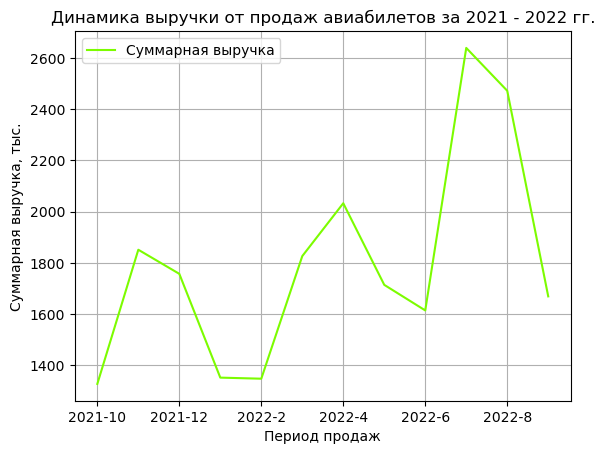

In [189]:
revenue_dynamics.plot(x='revenue_by_month', 
                      y='revenue_amount', 
                      grid=True, 
                      title='Динамика выручки от продаж авиабилетов за 2021 - 2022 гг.', 
                      xlabel='Период продаж', 
                      ylabel='Суммарная выручка, тыс.', 
                      label='Суммарная выручка',
                      color='#7CFC00')

Анализ месячной динамики выручки за 2021-2022 годы демонстрирует выраженную **сезонность продаж** авиабилетов. 

В ноябре 2021 года наблюдается пиковый рост выручки (за последние 3 месяца), достигающий максимальных значений, что традиционно связано с активизацией деловых поездок, подготовкой к зимнему сезону (люди покупают билеты заранее, дабы избежать закономерного роста цен в декабре). В ряде регионов Российской Федерации осенние школьные каникулы приходятся именно на этот период, что стимулирует семейные поездки и кратковременный отдых

Однако в декабре 2021 - январе 2022 года происходит закономерный спад, обусловленный сезонным снижением спроса на авиаперевозки. 

Весенние месяцы (февраль-апрель) 2022 года знаменуют постепенное восстановление объемов выручки, причем март и апрель стабилизируются на отметке около 2000 тысяч рублей. 

Летний период 2022 года показал классический сезонный пик в июле, когда выручка достигла максимальных значений. Этот рост обусловлен массовым спросом на авиаперевозки в основной отпускной период: школьные каникулы, благоприятная погода, традиционное планирование летнего отдыха. 

*<span style="color:#FF69B4">отчет с детализацией по **ffp_flag</span>***

In [190]:
revenue_FFP = air_data[air_data['revenue_amount'] != 0].pivot_table(index='revenue_by_month',
                                                                    aggfunc='sum',
                                                                    columns='ffp_flag',
                                                                    values='revenue_amount').reset_index()
revenue_FFP[['FFP', 'NO_FFP']] = revenue_FFP[['FFP', 'NO_FFP']] / 1000    #УКРУПНЕНИЕ
revenue_FFP

ffp_flag,revenue_by_month,FFP,NO_FFP
0,2021-10,502.03,825.81
1,2021-11,735.10,1116.16
2,2021-12,721.01,1036.24
3,2022-1,538.54,813.85
4,2022-2,499.24,848.97
5,2022-3,801.36,1025.07
6,2022-4,764.88,1267.69
7,2022-5,649.52,1064.72
8,2022-6,590.92,1023.58
9,2022-7,973.45,1664.98


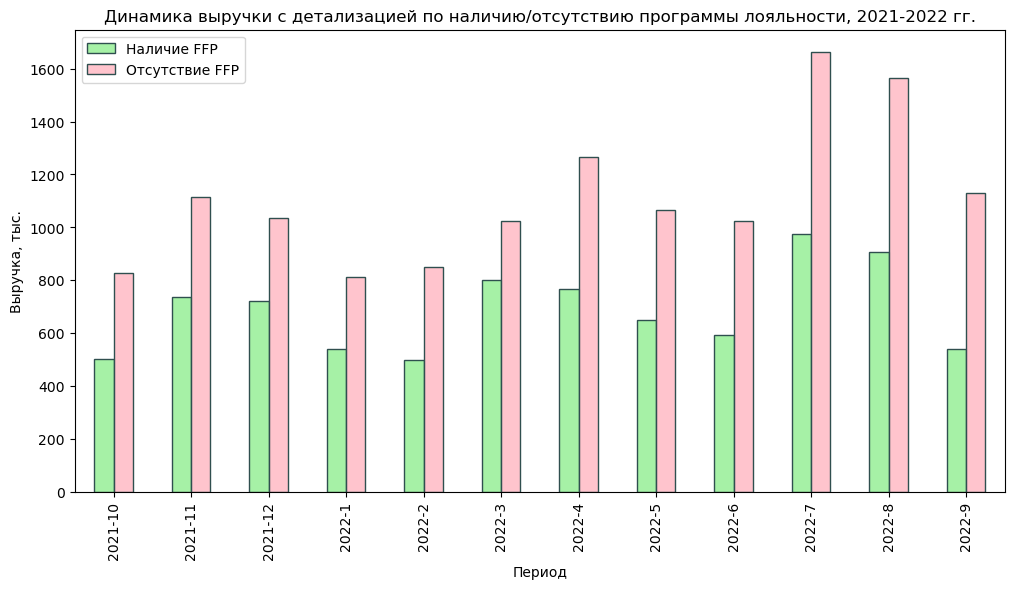

In [191]:
revenue_FFP.plot(kind='bar',
                 figsize=(12, 6),
                 x='revenue_by_month',
                 y=['FFP', 'NO_FFP'],
                 title='Динамика выручки с детализацией по наличию/отсутствию программы лояльности, 2021-2022 гг.',
                 xlabel='Период',
                 ylabel='Выручка, тыс.',
                 color=['#90EE90CC', '#FFB6C1CC'],
                 edgecolor='#2F4F4F',
                 label=["Наличие FFP", "Отсутствие FFP"])
plt.show()

По всем месяцам, выручка по группе **NO_FFP** (без программы лояльности) стабильно выше, чем по группе **FFP** (с программой лояльности). Максимальное расхождение наблюдается в июле-августе 2022 года: NO_FFP достигает 1664,98 и 1564,72 тыс. против 973,45 и 906,54 тыс. у FFP.

Основной период устойчивого **роста** выручки (по обеим группам) приходится на январь—апрель 2022 года.
Это может быть обусловлено: **подготовкой к летнему сезону** (весной люди более активно планируют отпуска, командировки и поездки), **реакцией на СВО** (в начале крупных геополитических событий обычно фиксируется скачок активности (реакция на неопределенность)).

Затем следует некоторый спад выручки, после чего наблюдается резкий всплеск в июле (вероятно, по причине проведения крупных маркетинговых акций, распродаж). Общий летний спад связан с **насыщением спроса**: основные билеты куплены заранее, часть клиентов уехала в отпуск. 

Таким образом, обе группы ведут себя схоже, одинаково реагируя на периоды роста и спада. Это показывает, что текущая программа лояльности не оказывает значимого влияния на увеличение выручки.

*<span style="color:#FF69B4">отчет с детализацией по **route_flight_type</span>***

In [192]:
revenue_route_flight_type= air_data[air_data['revenue_amount'] != 0].pivot_table(index='revenue_by_month',
                                                                        aggfunc='sum',
                                                                        columns='route_flight_type',
                                                                        values='revenue_amount').reset_index()
revenue_route_flight_type[['ВВЛ', 'МВЛ']] = revenue_route_flight_type[['ВВЛ', 'МВЛ']] / 1000    #УКРУПНЕНИЕ
revenue_route_flight_type

route_flight_type,revenue_by_month,ВВЛ,МВЛ
0,2021-10,1039.02,288.82
1,2021-11,1528.99,322.27
2,2021-12,1452.48,304.77
3,2022-1,1152.79,199.60
4,2022-2,1173.37,174.84
5,2022-3,1789.04,37.39
6,2022-4,1926.43,106.14
7,2022-5,1635.18,79.06
8,2022-6,1523.81,90.69
9,2022-7,2507.80,130.63


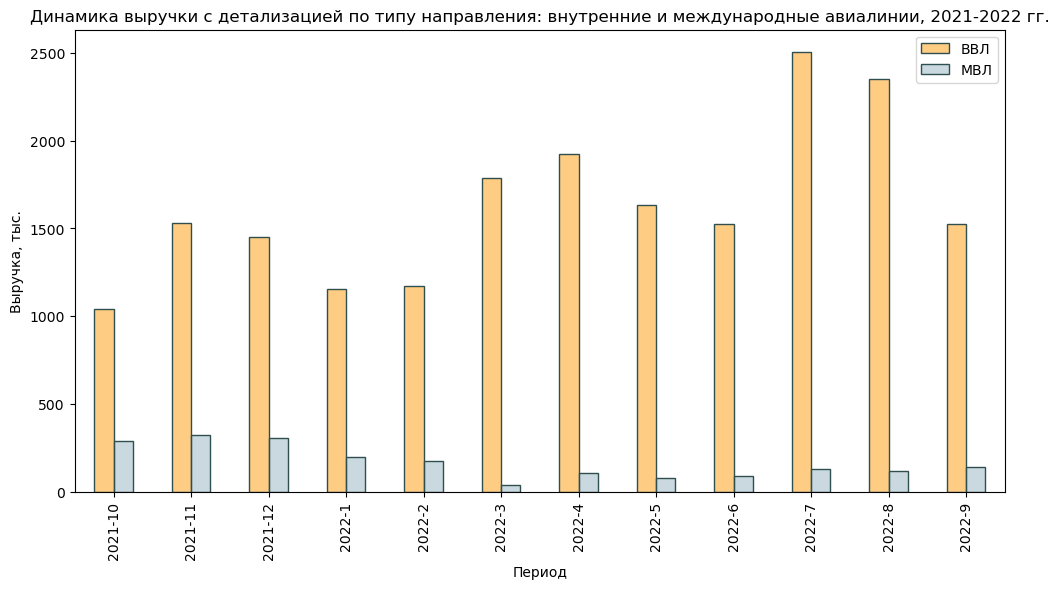

In [193]:
revenue_route_flight_type.plot(kind='bar',
                 figsize=(12, 6),
                 x='revenue_by_month',
                 y=['ВВЛ', 'МВЛ'],
                 title='Динамика выручки с детализацией по типу направления: внутренние и международные авиалинии, 2021-2022 гг.',
                 xlabel='Период',
                 ylabel='Выручка, тыс.',
                 color=['#FFB347AA', '#AEC6CFAA'],
                 edgecolor='#2F4F4F',
                 label=['ВВЛ', 'МВЛ'])
plt.show()

Динамика выручки **внутренних авиалиний** демонстрирует сезонность с ростом в весенне-летний период и спадом в осенне-зимние месяцы. Однако внутри сезонов наблюдаются значительные колебания, особенно заметные в летний период 2022 года, когда выручка достигала пиковых значений в июле (2,5 млн) при общей неравномерной динамике.

Традиционное снижение спроса на **международные** перелёты в зимние месяцы (после новогодних каникул) объясняет общий спад выручки в период с ноября 2021 г. по апрель 2022 г. Резкий обвал в марте 2022 связан с введением ограничений на международные перевозки и закрытием воздушного пространства. Скачок в июле 2022 объясняется сезонным пиком туризма и частичной адаптацией авиакомпаний к новым условиям через переориентацию на доступные направления (Турция, ОАЭ, Таиланд).
Общий тренд роста с апреля показывает постепенное восстановление спроса и выстраивание новых логистических цепочек, хотя докризисные объемы не достигнуты.

Таким образом, внутренние авиаперевозки демонстрируют устойчивую сезонную динамику, в то время как международные сохраняются на минимальном уровне. Наблюдается перераспределение пассажиропотока в пользу внутренних направлений.

*<span style="color:#FF69B4">отчет с детализацией по **sale_type</span>***

In [194]:
revenue_sale_type = air_data[air_data['revenue_amount'] != 0].pivot_table(index='revenue_by_month',
                                                                    aggfunc='sum',
                                                                    columns='sale_type',
                                                                    values='revenue_amount').reset_index()
revenue_sale_type[['ONLINE', 'OFFLINE']] = revenue_sale_type[['ONLINE', 'OFFLINE']] / 1000    #УКРУПНЕНИЕ
revenue_sale_type

sale_type,revenue_by_month,OFFLINE,ONLINE
0,2021-10,649.64,678.20
1,2021-11,901.14,950.12
2,2021-12,853.05,904.20
3,2022-1,623.90,728.49
4,2022-2,670.26,677.95
5,2022-3,796.02,1030.41
6,2022-4,1035.09,997.48
7,2022-5,744.45,969.79
8,2022-6,753.65,860.85
9,2022-7,1185.74,1452.69


<Axes: title={'center': 'Динамика выручки по каналам продаж: онлайн/оффлайн, 2021-2022 гг.'}, xlabel='Период', ylabel='Выручка, тыс.'>

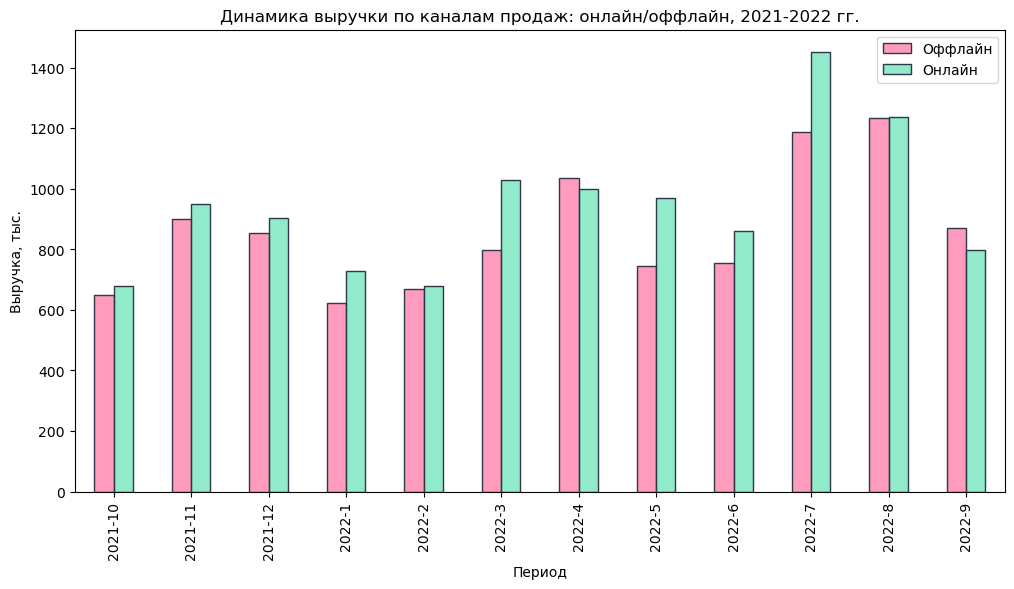

In [195]:
revenue_sale_type.plot(kind='bar',
                 figsize=(12, 6),
                 x='revenue_by_month',
                 y=['OFFLINE', 'ONLINE'],
                 title='Динамика выручки по каналам продаж: онлайн/оффлайн, 2021-2022 гг.',
                 xlabel='Период',
                 ylabel='Выручка, тыс.',
                 color=['#FF6B9DAA', '#5AE0B0AA'],
                 edgecolor='#2D3748',
                 label=['Оффлайн', 'Онлайн'])

**ONLINE-канал** демонстрирует устойчивое лидерство в 10 из 12 месяцев (кроме апр. и сент. 2022). Оба канала показывают максимальные значения в июле-августе 2022 (массовый спрос на авиаперелёты).

Цифровизация нарастает, что подтверждается сокращением периодов лидерства **OFFLINE**, однако канал традиционных продаж сохраняет 35-48% долю даже в цифровую эпоху по причине доверия к привычным методам покупки.

В февр. 2022 оба показателя почти сравниваются (сложно выделить основную причину), в августе аналогично, вероятно, из-за семейных отпусков, тургрупп через офлайн-агентства.

Общий тренд характеризуется переходом к **гибридной модели** продаж, где онлайн-канал обеспечивает массовость и эффективность, а офлайн-канал сохраняет устойчивость в нишевых сегментах. Оба канала дополняют друг друга, формируя сбалансированную экосистему продаж.

In [196]:
#детализация по типам пассажиров
revenue_pax_type = air_data[air_data['revenue_amount'] != 0].pivot_table(index='revenue_by_month',
                                                                        aggfunc='sum',
                                                                        columns='pax_type',
                                                                        values='revenue_amount').reset_index()
revenue_pax_type[['AD', 'CHD', 'INF']] = revenue_pax_type[['AD', 'CHD', 'INF']] / 1000    #укрупнение
revenue_pax_type

pax_type,revenue_by_month,AD,CHD,INF
0,2021-10,1244.72,81.20,1.92
1,2021-11,1745.06,105.46,0.74
2,2021-12,1668.19,88.38,0.68
3,2022-1,1282.04,69.39,0.96
4,2022-2,1265.08,82.32,0.81
5,2022-3,1721.67,104.44,0.32
6,2022-4,1910.77,120.98,0.82
7,2022-5,1539.75,173.57,0.92
8,2022-6,1487.77,125.80,0.93
9,2022-7,2427.88,210.14,0.41


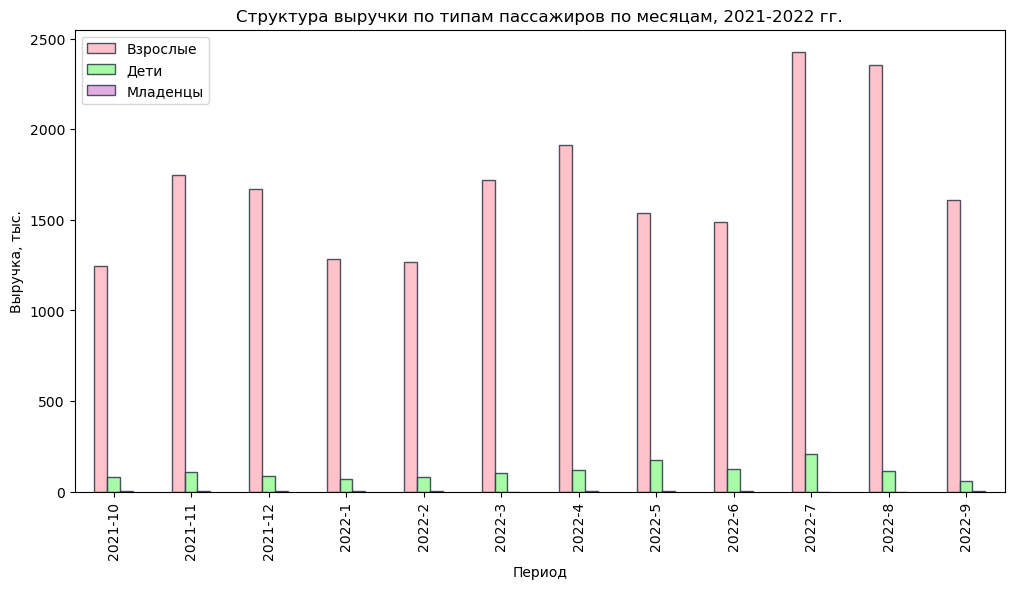

In [197]:
revenue_pax_type.plot(kind='bar',
                 figsize=(12, 6),
                 x='revenue_by_month',
                 y=['AD', 'CHD', 'INF'],
                 title='Структура выручки по типам пассажиров по месяцам, 2021-2022 гг.',
                 xlabel='Период',
                 ylabel='Выручка, тыс.',
                 color=['#FFB6C1', '#98FB98', '#DDA0DD'], 
                 alpha=0.85,
                 edgecolor='#2D3748',
                 label=['Взрослые', 'Дети', 'Младенцы'])
plt.show()

Выручка от категории **ADULT** (взрослые) составляет абсолютное большинство во всех месяцах (они чаще путешествуют и оплачивают полную стоимость билетов, для детей и младенцев зачастую действуют существенные скидки). 

Категория **CHILD** демонстрирует стабильный вклад в выручку на уровне 50-210 тыс. ежемесячно, с выраженным пиком в июле 2022 года (210.14 тыс.), что закономерно связано с увеличением семейных путешествий в период летних отпусков и каникул.
Доля **младенцев** в выручке минимальна, поскольку они перевозятся по символическим тарифам (обычно 10% от стоимости взрослого билета) и всегда летают только в сопровождении взрослых.

Октябрьский пик в 2021 года представляет собой аномалию на фоне общей тенденции минимальных показателей перевозки младенцев (выручка составила 1.92 тыс.). Возможно, это случайное групповое бронирование или единичная акция, которая не повторилась в другие месяцы. 

*<span style="color:#00BFFF">3.2 Исследуйте выручку, примите решение об исключении выбросов для дальнейшего исследования, руководствуясь минимизацией потерь в данных.*

In [198]:
positive_revenue = air_data[air_data['revenue_amount'] != 0]    #только выручка > 0

In [199]:
#генерируем описательную статистику выручки по продажам
positive_revenue['revenue_amount'].describe()

count    49365.000000
mean       437.631723
std        214.604891
min         10.000000
25%        290.000000
50%        400.000000
75%        550.000000
max       5200.000000
Name: revenue_amount, dtype: float64

Распределение выручки имеет правостороннюю асимметрию (среднее больше медианы). Половина значений группируется в диапазоне от 0 до 550.

<Axes: >

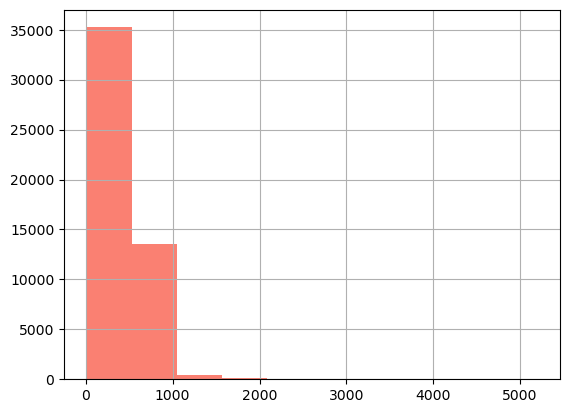

In [200]:
positive_revenue['revenue_amount'].hist(color='salmon')

Большая часть выручки сконцентрирована в низких значениях (на интервале 0–1000), а правые значения распределения практически не встречаются.
Небольшое число наблюдений имеют очень высокую выручку (до 5000), что говорит о наличии выбросов (?). Распределение не похоже на нормальное, присутствуют экстремальные значения.

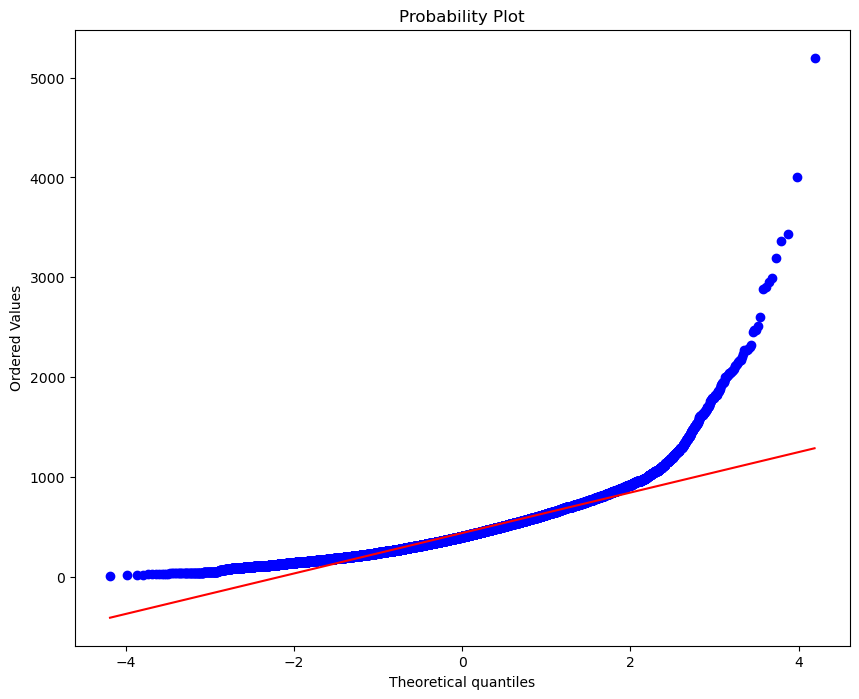

In [201]:
plt.figure(figsize = (10, 8))
st.probplot(positive_revenue['revenue_amount'], dist='norm', plot=plt)
plt.show()

Распределение существенно **отклоняется** от нормального, так как точки не ложатся на диагональную линию

In [202]:
q75 = np.percentile(positive_revenue['revenue_amount'], 75)    #для идентификации выбросов используем iqr, он больше подходит для скошенных распределений, 
#поскольку использует квартили, которые устойчивы к экстр. значениям. В целом не требует предположений о форме распределения.
q25 = np.percentile(positive_revenue['revenue_amount'], 25)
iqr = q75 - q25
ejection_h = q75 + 1.5 * iqr    #верхняя граница выбросов
ejection_l = q25 - 1.5 * iqr    #нижняя граница выбросов
print(ejection_h, ejection_l)

940.0 -100.0


In [203]:
#количество выбросов
n_ejection = positive_revenue[(positive_revenue['revenue_amount'] > ejection_h) | (positive_revenue['revenue_amount'] < ejection_l)]['revenue_amount'].count()
print(f"Число выбросов: {n_ejection}")

Число выбросов: 987


In [204]:
ejection_perc = ((n_ejection / len(positive_revenue['revenue_amount'])) * 100).round(3)
print(f"% выбросов: {ejection_perc}")

% выбросов: 1.999


In [205]:
positive_revenue['revenue_amount'].describe()

count    49365.000000
mean       437.631723
std        214.604891
min         10.000000
25%        290.000000
50%        400.000000
75%        550.000000
max       5200.000000
Name: revenue_amount, dtype: float64

Исходные данные являются достаточно "чистыми", процент выбросов составил порядка 2%, что в целом **нормально** для такого объема данных.

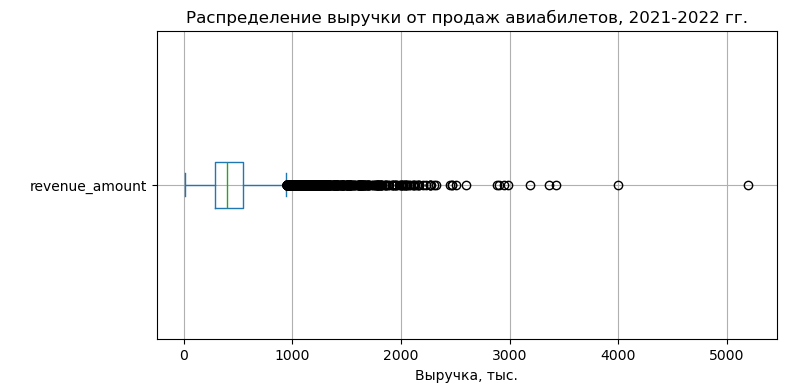

In [206]:
positive_revenue['revenue_amount'].plot(kind='box', figsize=(8, 4), grid=True, vert=False, title='Распределение выручки от продаж авиабилетов, 2021-2022 гг.', 
                                xlabel='Выручка, тыс.',
                                ylabel=' ')
plt.show()

Распределение выручки демонстрирует ярко выраженную **правостороннюю асимметрию** (среднее > медианы, выбросы сосредоточены в правой части боксплота), что достаточно типично для данного вида бизнеса (невозможно иметь отрицательную выручку (в нормальных условиях)). Медиана чуть смещена к нижней части ящика, меньше среднего (за счет большого объема мелких сделок и небольшой части крупных), правый ус длинее из-за ограниченного числа сделок с аномально высокой выручкой.

Такие экстремальные значения по своей сути ценная часть бизнеса, которая может включать групповые бронирования, продажи бизнес-класса и премиальных тарифов, дальнемагистральные перелеты, продажи в пиковые сезоны и тд.

Необходимо подумать, что же делать с небольшой горсткой экстремальных значений.

In [207]:
air_data_clean = positive_revenue[positive_revenue['revenue_amount'] <= ejection_h] #оставляем все, что ниже верхней границы 
# (нижнюю не берем, там выбросы отсутствуют, выручка не может быть отрицательной)
air_data_outliers = positive_revenue[positive_revenue['revenue_amount'] > ejection_h]    #только "выбросы"

In [208]:
print(len(positive_revenue) - len(air_data_clean))    #проверочка, все чисто

987


<Axes: >

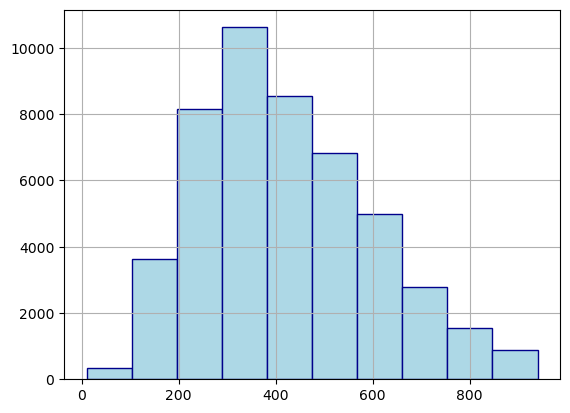

In [209]:
air_data_clean['revenue_amount'].hist(color='lightblue', edgecolor='darkblue')

Большинство значений сконцентрировано в левой части графика (небольшие суммы), при этом присутствует длинный правый хвост, состоящий из редких, но крупных транзакций

In [210]:
air_data_clean['revenue_amount'].describe()    #описательная статистика для нормальной выручки
#распределение более (если можно так говорить) симметрично (медиана и среднее близки)

count    48378.000000
mean       421.942205
std        178.542393
min         10.000000
25%        280.000000
50%        400.000000
75%        540.000000
max        940.000000
Name: revenue_amount, dtype: float64

In [211]:
air_data_outliers['revenue_amount'].describe()    #описательная статистика для экстремальной выручки
#сильная правосторонняя асимметрия (медиана 1060, среднее 1192,6)

count     987.000000
mean     1206.656535
std       371.007846
min       950.000000
25%       980.000000
50%      1070.000000
75%      1260.000000
max      5200.000000
Name: revenue_amount, dtype: float64

In [212]:
print(f"Доля выручки, которую приносят обычные клиенты: {air_data_clean['revenue_amount'].sum() / (air_data_clean['revenue_amount'].sum() + air_data_outliers['revenue_amount'].sum())}")

Доля выручки, которую приносят обычные клиенты: 0.9448719177140572


In [213]:
print(f"Доля выручки, которую приносят экстремальные клиенты: {air_data_outliers['revenue_amount'].sum() / (air_data_clean['revenue_amount'].sum() + air_data_outliers['revenue_amount'].sum())}")

Доля выручки, которую приносят экстремальные клиенты: 0.05512808228594282


Получается, что основной сегмент приносит 94% выручки, характеризуется относительно **стабильными показателями** (медиана и среднее практически равны), дорогой сегмент приносит 6% выручки и демонстрирует **эктремально высокие чеки** (среднее порядка 1200 тыс.). Для анализа среднерыночных показателей и прогнозирования лучше использовать данные без учета экстремального сегмента, для отчетности по общей выручке можно брать полные данные.

Для минимизации потерь данных выбросы **не удалялись** полностью. Было создано два набора: с выбросами и без них. При дальнейшем анализе будет выбран подходящий вариант в зависимости от задачи.


*<span style="color:#00BFFF">3.3 Исследуйте сезонность продаж. Дополнительно проверьте гипотезу о том, что выручка от продаж осенью и зимой отличается. Исследуйте выручку и число продаж по месяцам, проверьте корреляцию.*

Для анализа сезонности продаж будем использовать выручку **без** учета экстремальных значений. Без них сезонные тренды становятся более наглядными, так как исключаются случайные всплески, и в результате выявляются типичные паттерны спроса для каждого сезона.

In [214]:
seasonality_of_sales = air_data_clean[air_data_clean['revenue_amount'] != 0].groupby('revenue_by_month')['revenue_amount'].sum()
seasonality_of_sales = seasonality_of_sales.reset_index(drop=False)
seasonality_of_sales['revenue_amount'] = seasonality_of_sales['revenue_amount'] / 1000
seasonality_of_sales

,revenue_by_month,revenue_amount
0,2021-10,1280.87
1,2021-11,1766.94
2,2021-12,1666.01
3,2022-1,1304.09
4,2022-2,1297.63
5,2022-3,1759.96
6,2022-4,1934.20
7,2022-5,1652.56
8,2022-6,1538.60
9,2022-7,2447.96


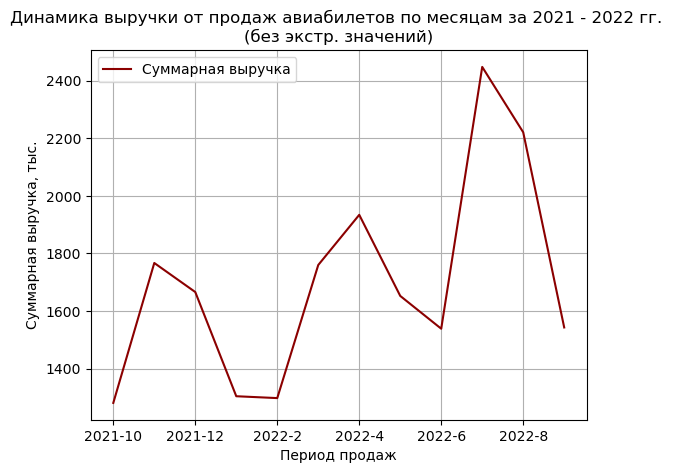

In [215]:
seasonality_of_sales.plot(x='revenue_by_month', 
                      y='revenue_amount', 
                      grid=True, 
                      title='Динамика выручки от продаж авиабилетов по месяцам за 2021 - 2022 гг. \n(без экстр. значений)', 
                      xlabel='Период продаж', 
                      ylabel='Суммарная выручка, тыс.', 
                      label='Суммарная выручка',
                      color='#8B0000')
plt.show()

*Итоги:*
1. В осенний период (окт. - ноябрь 2021 г.) наблюдается заметный рост выручки, который достигает пика в ноябре.
Причина роста вероятно заключается в увеличении рабочих командировок, деловых поездок после летнего сезона, массовой ранней покупке билетов к зимним праздникам. Кроме того, авиакомпания может проводить акции, скидки на будущие рейсы, что стимулирует рост продаж.
2. Зимний период (дек. - февр. 2022 г.) характеризуется существенноым снижением выручки, сохраняющимся в течение всей зимы. Спад связан с завершением новогодних праздников, неблагоприятными погодными условиями для отдыха.
3. Весенний период (март - апр. 2022 г.) восстановление спроса и рост выручки, в апреле — локальный максимум. Причина вероятно в подготовке к майским праздникам и летнему отпускному сезону.
4. Межсезонье (май 2022 г.): наблюдается снижение выручки. Снижение выручки в мае часто связано с тем, что после весенних праздников и перед началом летних отпусков часть клиентов откладывает покупки авиабилетов.
5. Летний период: начинается новая волна роста, пик приходится на июль 2022. Рост выручки летом до июля объясняется массовым отпускным сезоном и увеличением числа путешествий.
6. Начало осени 2022: наблюдается спад, формируя переход к новому осеннему циклу. Спад выручки к сентябрю связан с тем, что большинство отпусков завершено, и обратные билеты, как правило, приобретаются одновременно с билетами на поездку, поэтому дополнительный спрос на авиаперевозки к осени существенно уменьшается.

Наблюдается следующая тенденция: рост в осенний период за счет деловых поездок и праздников, снижение зимой, возобновление спроса весной, спад в межсезонье мая, пик летом на волне отпусков и очередное снижение к началу осени в преддверии нового цикла.

*<span style="color:#FF69B4">Дополнительно проверьте гипотезу о том, что выручка от продаж осенью и зимой отличается</span>*

В связи с недостатком данных за полную осень 2021 года (отсутствует сентябрь 2021), возьмем сентябрь 2022 года (как дополнение для более полной картины осеннего периода).

In [216]:
sales_revenue_in_the_fall = air_data_clean[air_data_clean['revenue_amount'] != 0].query('month.isin([9, 10,11])')
sales_revenue_in_the_fall
# фильтрация

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year,month,day,revenue_by_month
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,11,28,2021-11
5,2021-11-29,2022-01-14,AD,250,MOW,DUS,МВЛ,NO_FFP,ONLINE,2021,11,29,2021-11
7,2021-11-28,2022-01-07,CHD,70,MOW,AER,ВВЛ,FFP,ONLINE,2021,11,28,2021-11
9,2021-11-25,2022-01-03,AD,280,MOW,KUF,ВВЛ,NO_FFP,ONLINE,2021,11,25,2021-11
11,2021-11-28,2022-01-12,AD,380,OVB,AER,ВВЛ,FFP,ONLINE,2021,11,28,2021-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49455,2021-10-08,2021-12-10,AD,240,KGD,MOW,ВВЛ,NO_FFP,OFFLINE,2021,10,8,2021-10
49456,2021-10-07,2021-12-01,AD,310,NJC,OVB,ВВЛ,NO_FFP,ONLINE,2021,10,7,2021-10
49457,2021-10-29,2021-12-03,AD,440,OVB,FEG,МВЛ,NO_FFP,OFFLINE,2021,10,29,2021-10
49459,2021-10-16,2021-12-17,AD,400,MOW,UUD,ВВЛ,NO_FFP,ONLINE,2021,10,16,2021-10


In [217]:
sales_revenue_in_the_winter = air_data_clean[air_data_clean['revenue_amount'] != 0].query('month.isin([12, 1, 2])')
sales_revenue_in_the_winter

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year,month,day,revenue_by_month
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,2021,12,7,2021-12
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO_FFP,OFFLINE,2021,12,31,2021-12
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO_FFP,ONLINE,2021,12,8,2021-12
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021,12,8,2021-12
6,2021-12-03,2022-01-06,AD,200,MOW,PEE,ВВЛ,FFP,ONLINE,2021,12,3,2021-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49404,2021-12-27,2021-12-28,AD,510,KJA,MOW,ВВЛ,NO_FFP,OFFLINE,2021,12,27,2021-12
49432,2021-12-22,2021-12-28,AD,620,VVO,PKC,ВВЛ,NO_FFP,OFFLINE,2021,12,22,2021-12
49437,2021-12-01,2021-12-16,AD,390,MOW,MMK,ВВЛ,NO_FFP,OFFLINE,2021,12,1,2021-12
49440,2021-12-27,2021-12-31,AD,650,OVB,PKC,ВВЛ,NO_FFP,OFFLINE,2021,12,27,2021-12


In [218]:
sales_fall = sales_revenue_in_the_fall.pivot_table(index='day',
                                                   aggfunc='sum',
                                                   values='revenue_amount').reset_index()
sales_fall['revenue_amount'] = sales_fall['revenue_amount'] / 1000

In [219]:
sales_winter = sales_revenue_in_the_winter.pivot_table(index='day',
                                                   aggfunc='sum',
                                                   values='revenue_amount').reset_index()
sales_winter['revenue_amount'] = sales_winter['revenue_amount'] / 1000

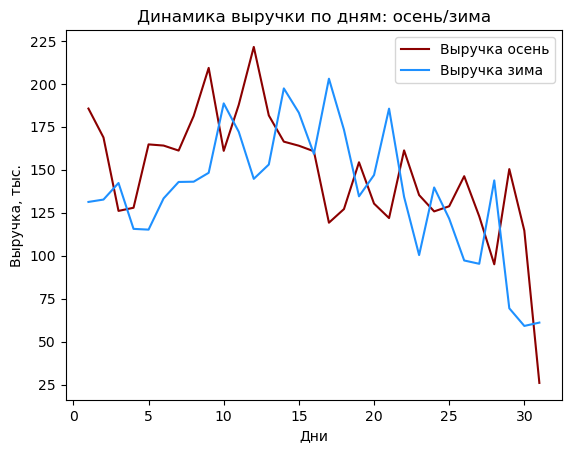

In [220]:
sns.lineplot(data = sales_fall, x='day', y='revenue_amount', label='Выручка осень', color='#8B0000')
sns.lineplot(data = sales_winter, x='day', y='revenue_amount', label='Выручка зима', color='#1E90FF')
plt.xlabel('Дни')
plt.ylabel('Выручка, тыс.')
plt.title('Динамика выручки по дням: осень/зима')
plt.show()

Если говорить про общую картину, то можно прийти к следующему выводу: осенняя выручка доминирует над зимней в начале месяца/до первой его половины (возможно, связано с получением зарплат, началом учебного года, подготовкой к зиме).
Доминирование зимней выручки наблюдается к середине месяца (может быть связано с предпраздничными покупками, распродажами).
Далее нестабильная динамика. Оба сезона показывают схожую тенденцию к снижению выручки к концу месяца, что может указывать на общие месячные циклы покупательской активности независимо от времени года.

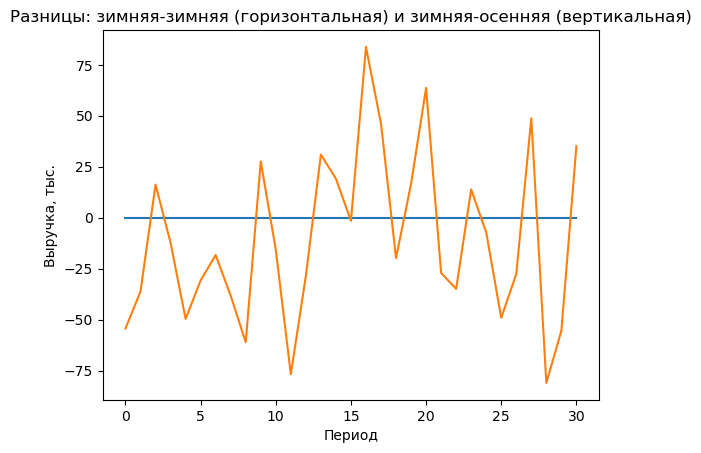

In [221]:
plt.plot(sales_winter - sales_fall)
plt.title('Разницы: зимняя-зимняя (горизонтальная) и зимняя-осенняя (вертикальная)')
plt.xlabel('Период')
plt.ylabel('Выручка, тыс.')
plt.show()

В первые дне недели осенняя выручка стабильно превышает зимнюю. К середине периода зимняя выручка начинает лидировать. Это может быть связано с новогодними продажами, ростом спроса в предпраздничный период или успешными зимними акциями.

После 21 дня наблюдается переменный успех: осенняя выручка чаще показывает лучшие результаты, но зимняя периодически демонстрирует всплески. Это говорит о нестабильности зимних продаж в конце сезона, возможно из-за постпраздничного спада.

Зимний сезон показывает характеризуется сильным средним периодом, но слабыми началом и окончанием, тогда как осенняя выручка более стабильна.

Text(0.5, 1.0, 'Зимняя выручка')

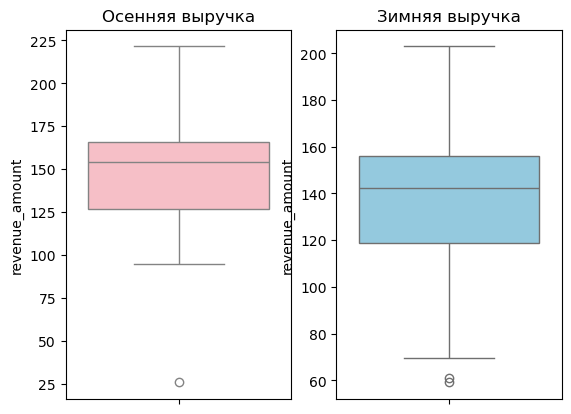

In [222]:
#посмотрим на распределение
plt.subplot(1, 2, 1)
sns.boxplot(y=sales_fall['revenue_amount'], color='#FFB6C1')
plt.title('Осенняя выручка')
plt.subplot(1, 2, 2)
sns.boxplot(y=sales_winter['revenue_amount'], color='#87CEEB')
plt.title('Зимняя выручка')

In [223]:
sales_fall['revenue_amount'].describe()

count     31.000000
mean     148.090000
std       36.642078
min       26.000000
25%      126.595000
50%      154.350000
75%      165.550000
max      221.450000
Name: revenue_amount, dtype: float64

In [224]:
sales_winter['revenue_amount'].describe()

count     31.000000
mean     137.668710
std       37.042656
min       59.150000
25%      118.590000
50%      142.300000
75%      156.120000
max      202.960000
Name: revenue_amount, dtype: float64

Медианное значение осенней выручки составляет порядка 148 тыс., тогда как зимний показатель почти достигает 138 единиц. Такой разрыв свидетельствует о систематически более **высоком** уровне выручки в осенний период.

Стандартные отклонения близки (36.6/37), можно говорить о **сопоставимости степени разброса данных** в обоих сезонах. 

Осенняя выручка имеет выраженную **левостороннюю асимметрию** (большая часть данных сконцентрирована в верхней части шкалы, но есть несколько низких значений (мин. один выброс, что тянет среднее вниз)). Верхний ус значительно длиннее, что указывает на большую вариативность в успешные дни.
Кроме того, визуально зимний боксплот выглядит более сбалансированным (хотя есть такое же подозрение на левостороннюю асиммметрию, медиана > среднего), тогда как осенний имеет явный перекос вверх с длинным верхним усом.

У осеннего периода один, но более экстремальный выброс (26 ед.), что указывает на редкие, но глубокие провалы в выручке. Зимний период имеет два менее выраженных выброса, что говорит о более частых, но не таких значительных спадах.

<span style="color:#B22222">Выше мы выявили, что распределение осенней выручки имеет выраженную **левостороннюю асимметрию** и не соответствует нормальному распределению. Для статистического подтверждения проведем формальную проверку - тест Шапиро-Уилка.</span>

In [225]:
#H0: выборка имеет нормальное распределение
#H0: выборка НЕ имеет нормальное распределение
stat, p = st.shapiro(sales_fall['revenue_amount'])

alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка НЕ имеет нормального распределения')
else:
    print(p, 'Принимаем нулевую гипотезу. Выборка имеет нормальное распределение')

0.03287380053158902 Отвергаем нулевую гипотезу. Выборка НЕ имеет нормального распределения


In [226]:
stat, p = st.shapiro(sales_winter['revenue_amount'])

alpha = 0.05
if p < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка НЕ имеет нормального распределения')
else:
    print(p, 'Принимаем нулевую гипотезу. Выборка имеет нормальное распределение')

0.2678352966094446 Принимаем нулевую гипотезу. Выборка имеет нормальное распределение


<span style="color:#B22222">По результатам теста Шапиро-Уилка подтвердилось, что распределение осенней выручки **не** является нормальным. В этом случае использование t-теста некорректно.</span>

Для сравнения сезонов воспользуемся **непараметрическим тестом Манна-Уитни**, который не требует предположения о нормальности распределения и устойчив к выбросам.

In [227]:
alpha = 0.05
# если п_вэлью окажется меньше него, отвергаем гипотезу
results = st.mannwhitneyu(sales_fall['revenue_amount'], sales_winter['revenue_amount'])
print('p_value:', results.pvalue)
if results.pvalue < alpha:
    print('Гипотеза отвергается, ЕСТЬ статистически значимые различия между выборками')
else:
    print('Гипотеза принимается, НЕТ статистически значимых различий между выборками')

p_value: 0.3040740898177029
Гипотеза принимается, НЕТ статистически значимых различий между выборками


На основании теста Манна-Уитни принимаем нулевую гипотезу: **статистически значимых различий в выручке между осенним и зимним сезонами не обнаружено**. Несмотря на визуальные различия в распределениях и средних значениях, статистический анализ показывает, что эти различия могут быть случайными и не носят систематического характера.

*<span style="color:#00BFFF">Исследуем выручку и число продаж по месяцам, проверим корреляцию.*

In [228]:
air_data_clean

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year,month,day,revenue_by_month
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,2021,12,7,2021-12
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO_FFP,OFFLINE,2021,12,31,2021-12
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,11,28,2021-11
3,2021-12-08,2022-01-05,AD,190,VOZ,MOW,ВВЛ,NO_FFP,ONLINE,2021,12,8,2021-12
4,2021-12-08,2022-01-12,AD,190,MOW,KRR,ВВЛ,FFP,OFFLINE,2021,12,8,2021-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49826,2022-06-11,2022-06-22,CHD,480,MOW,OMS,ВВЛ,NO_FFP,ONLINE,2022,6,11,2022-6
49827,2022-06-06,2022-06-20,AD,270,LED,MOW,ВВЛ,NO_FFP,OFFLINE,2022,6,6,2022-6
49828,2022-06-26,2022-06-29,AD,230,MOW,KZN,ВВЛ,FFP,ONLINE,2022,6,26,2022-6
49829,2022-06-26,2022-06-28,AD,270,KZN,MOW,ВВЛ,NO_FFP,OFFLINE,2022,6,26,2022-6


In [229]:
sales_ = air_data_clean.query("revenue_amount != 0").pivot_table(index='revenue_by_month',
                                                                               aggfunc=['sum', 'count'],
                                                                               values='revenue_amount').reset_index()
sales_.columns = ['month', 'revenue_sum', 'number_of_sales']
sales_['revenue_sum'] = sales_['revenue_sum'] / 1000 # в тыс.
sales_

,month,revenue_sum,number_of_sales
0,2021-10,1280.87,3579
1,2021-11,1766.94,5109
2,2021-12,1666.01,4490
3,2022-1,1304.09,3552
4,2022-2,1297.63,3415
5,2022-3,1759.96,4275
6,2022-4,1934.20,3887
7,2022-5,1652.56,3565
8,2022-6,1538.60,3287
9,2022-7,2447.96,5093


array([[<Axes: title={'center': 'revenue_sum'}>,
        <Axes: title={'center': 'number_of_sales'}>]], dtype=object)

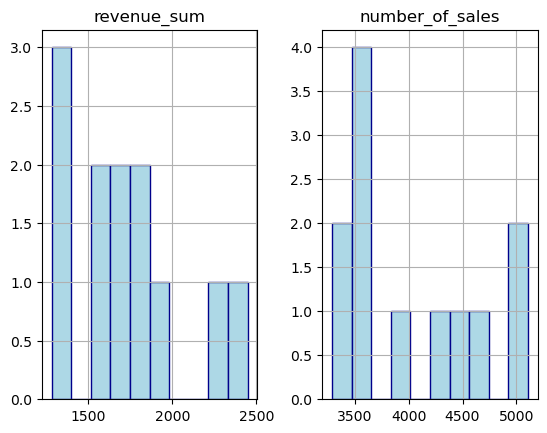

In [230]:
sales_[['revenue_sum', 'number_of_sales']].hist(color='lightblue', edgecolor='darkblue')

По гистограммам видно, что и суммарная выручка, и число продаж по месяцам распределены не очень **неравномерно**. Есть небольшая кучность значений внизу диапазона и несколько месяцев с заметно более высокой выручкой/продажами.

In [231]:
# но проверим
#H0: выборка имеет нормальное распределение
#H0: выборка НЕ имеет нормальное распределение
stat, pv = st.shapiro(sales_['revenue_sum'])

alpha = 0.05
if pv < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка НЕ имеет нормального распределения')
else:
    print(p, 'Принимаем нулевую гипотезу. Выборка имеет нормальное распределение')

0.2678352966094446 Принимаем нулевую гипотезу. Выборка имеет нормальное распределение


In [232]:
stat, pv_2 = st.shapiro(sales_['number_of_sales'])

alpha = 0.05
if pv_2 < alpha:
    print(p, 'Отвергаем нулевую гипотезу. Выборка НЕ имеет нормального распределения')
else:
    print(p, 'Принимаем нулевую гипотезу. Выборка имеет нормальное распределение')

0.2678352966094446 Принимаем нулевую гипотезу. Выборка имеет нормальное распределение


Получается, что выборки имеют **норм. распределение**. Визуальные ступеньки на гистограмме, скорее всего, следствие малого числа месяцев, а не реального отклонения от нормы.

<Figure size 1000x1000 with 0 Axes>

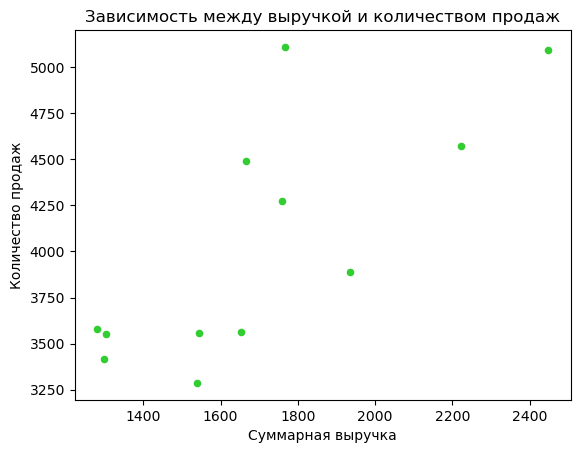

In [233]:
plt.figure(figsize=(10, 10))
sales_.plot(kind='scatter', x='revenue_sum', y='number_of_sales', color='limegreen')
plt.title('Зависимость между выручкой и количеством продаж')
plt.xlabel('Суммарная выручка')
plt.ylabel('Количество продаж')
plt.show()

По диаграмме рассеяния видно, что с ростом количества заказов в основном растет и выручка. Точки в целом выстраиваются в направлении слева снизу вправо вверх.

При этом есть месяцы, которые выбиваются из общего тренда: **апрель 2022** (при среднем числе заказов высокая выручка (1943.70), **март 2022** (при большом числе заказов (4278) относительно невысокая выручка).

Это говорит о том, что на выручку влияет не только количество заказов, но и другие факторы: средний чек, сезон и тд. Визуально связь между количеством заказов и выручкой прослеживается, но не является строгой. Для точных выводов нужны статистические расчеты.

Для измерения силы и направления связи между выручкой и количеством продаж целесообразно использовать **коэффициент ранговой корреляции Спирмена**, поскольку он не требует строгого соблюдения условия нормальности распределения (хотя выборки нормальны) и устойчив к наличию выбросов в данных, что особенно важно при анализе показателей с потенциальными аномальными значениями.

<Axes: >

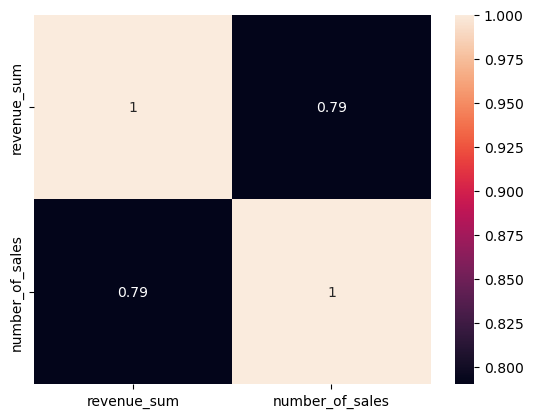

In [234]:
corr = sales_[['revenue_sum', 'number_of_sales']].corr(method='spearman')
sns.heatmap(corr, annot=True)

Между выручкой и количеством продаж наблюдается **сильная положительная** корреляция (0.79). Это означает, что при увеличении количества продаж выручка демонстрирует статистически значимую тенденцию к росту, и наоборот. 

Полученное значение свидетельствует о согласованном изменении анализируемых показателей, но **не доказывает**, что рост продаж является причиной увеличения выручки (и наоборот).

<span style="color:#8B0000">3.4 Клиенты покупают билеты в разное время. Кто-то покупает билеты заранее, другие - в последний момент. Проверьте гипотезу о том, что выручка от продажи билетов для этих двух групп клиентов **отличается**. Предварительно разбейте клиентов минимум на три группы.</span>

При анализе сезонности мы исключали выбросы, чтобы **выявить общие тренды**, не искаженные единичными аномалиями. Теперь же, при сегментации клиентов, выбросы лучше также удалить, чтобы группы формировались вокруг типичных паттернов покупок, а не искажались единичными аномальными значениями выручки.

In [235]:
air_data_clean = air_data_clean.copy()
air_data_clean['days_before_departure'] = (air_data_clean['flight_date_loc'] - air_data_clean['issue_date']).dt.days    #создаем столбец "количество дней до вылета", 
#преобразуем разницу между датами в целые числа (дни), что позволяет корректно категоризировать клиентов по времени покупки
air_data_clean.head(3)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year,month,day,revenue_by_month,days_before_departure
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,2021,12,7,2021-12,35
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO_FFP,OFFLINE,2021,12,31,2021-12,3
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,11,28,2021-11,37


Делим клиентов на 3 группы по времени покупки до вылета:

late_purchase — купили за 0-7 дней (последняя неделя)

optimal_purchase — за 8-30 дней (оптимальный период)

early_purchase — за 31+ дней (заранее)

In [288]:
air_data_clean['cust_categorization'] = pd.cut(air_data_clean['days_before_departure'],    #осуществляем категоризацию
                          bins=[0, 7, 30, air_data_clean['days_before_departure'].max() + 1],
                          labels=['late_purchase', 'optimal_purchase', 'early_purchase'], right=True)
air_data_clean.head(3)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year,month,day,revenue_by_month,days_before_departure,cust_categorization
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,2021,12,7,2021-12,35,early_purchase
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO_FFP,OFFLINE,2021,12,31,2021-12,3,late_purchase
2,2021-11-28,2022-01-04,AD,390,KGD,MOW,ВВЛ,FFP,ONLINE,2021,11,28,2021-11,37,early_purchase


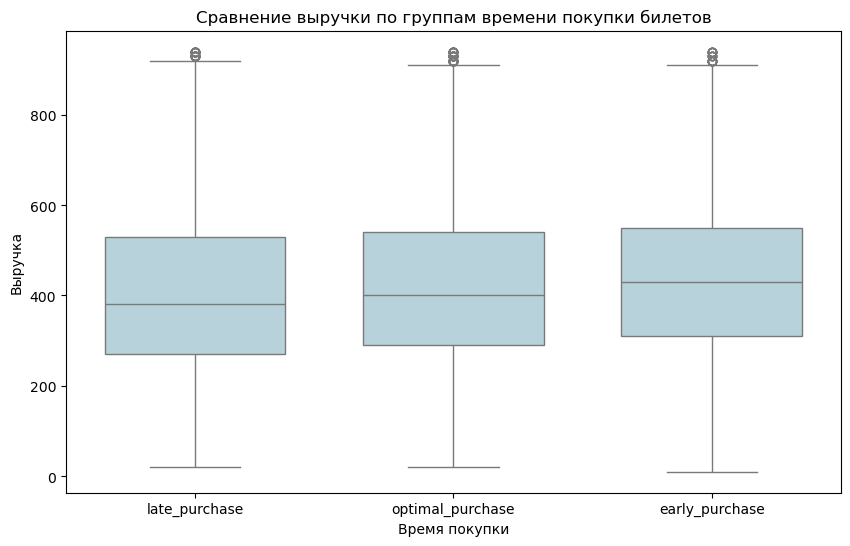

In [289]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=air_data_clean[air_data_clean['revenue_amount'] != 0], x='cust_categorization', y='revenue_amount', color='lightblue', 
            saturation=0.6,
            width=0.7)
plt.title('Сравнение выручки по группам времени покупки билетов')
plt.xlabel('Время покупки')
plt.ylabel('Выручка')
plt.show()

In [292]:
air_data_clean[air_data_clean['revenue_amount'] != 0].groupby('cust_categorization')['revenue_amount'].describe().reset_index()

C:\Users\uliza\AppData\Local\Temp\ipykernel_8844\3899017495.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  air_data_clean[air_data_clean['revenue_amount'] != 0].groupby('cust_categorization')['revenue_amount'].describe().reset_index()


,cust_categorization,count,mean,std,min,25%,50%,75%,max
0,late_purchase,19905.0,414.573223,179.114919,20.0,270.0,380.0,530.0,940.0
1,optimal_purchase,17414.0,424.888595,181.005876,20.0,290.0,400.0,540.0,940.0
2,early_purchase,9750.0,437.741538,172.622091,10.0,310.0,430.0,550.0,940.0


Группа **раннего** бронирования демонстрирует наиболее высокие и стабильные показатели выручки при наименьшем количестве клиентов. Здесь зафиксирована самая высокая средняя выручка (437.8) и максимальный медианный чек (430 единиц). Ранние покупатели чаще приобретают билеты по стандартным тарифам без спешки, что обеспечивает стабильно высокие средние чеки.

Группа **оптимального** бронирования показывает средние результаты по всем параметрам: 17 410 клиентов при средней выручке 424.9 единиц, что практически равно показателям ранних бронирований, однако с большим разбросом значений.

**Позднее бронирование**: при наибольшем объеме клиентской базы здесь наблюдается наименьший медианный чек (380 единиц) и средняя вариативность показателей (в сравнении с другими группами). У поздних бронирований среднее и медиана ниже, потому что основной объем продаж составляют бюджетные туристы, покупающие билеты по резко сниженным ценам перед вылетом (различные горящие туры, хотя есть немного дорогих срочных бронирований, но их доля слишком мала, чтобы компенсировать массу дешевых покупок). 

*<span style="color:#8B0000">Проверим гипотезу о том, что выручка от продаж отличается</span>*

Сначала проверим попарные различия между группами с помощью теста **Манна-Уитни**, который устойчив к нарушению нормальности распределения. Затем применим поправку Холма для контроля уровня ложных открытий при множественных сравнениях, что позволит определить статистически значимые различия

In [291]:
ear_p = air_data_clean[(air_data_clean['cust_categorization'] == 'early_purchase') & (air_data_clean['revenue_amount'] != 0)]['revenue_amount'].reset_index()
op_p = air_data_clean[(air_data_clean['cust_categorization'] == 'optimal_purchase') & (air_data_clean['revenue_amount'] != 0)]['revenue_amount'].reset_index()
late_p = air_data_clean[(air_data_clean['cust_categorization'] == 'late_purchase') & (air_data_clean['revenue_amount'] != 0)]['revenue_amount'].reset_index()

In [240]:
#H0: выручка от продаж по группам НЕ отличается
#H1: выручка от продаж по группам отличается
# сначала раннее брон. & оптимальное
alpha = 0.05
results_1 = st.mannwhitneyu(ear_p['revenue_amount'], op_p['revenue_amount'])
p_valu1 = results_1.pvalue
print('p_value:', p_valu1)
if p_valu1 < alpha:
    print('Гипотеза отвергается, ЕСТЬ статистически значимые различия между выборками')
else:
    print('Гипотеза принимается, НЕТ статистически значимых различий между выборками')

p_value: 1.0198315972425981e-13
Гипотеза отвергается, ЕСТЬ статистически значимые различия между выборками


In [241]:
# раннее брон. & позднее
results_2 = st.mannwhitneyu(ear_p['revenue_amount'], late_p['revenue_amount'])
p_valu2 = results_2.pvalue
print('p_value:', p_valu2)
if p_valu2 < alpha:
    print('Гипотеза отвергается, ЕСТЬ статистически значимые различия между выборками')
else:
    print('Гипотеза принимается, НЕТ статистически значимых различий между выборками')

p_value: 1.193946481110269e-40
Гипотеза отвергается, ЕСТЬ статистически значимые различия между выборками


In [242]:
# раннее оптим. & позднее
results_3 = st.mannwhitneyu(op_p['revenue_amount'], late_p['revenue_amount'])
p_valu3 = results_3.pvalue
print('p_value:', p_valu3)
if p_valu3 < alpha:
    print('Гипотеза отвергается, ЕСТЬ статистически значимые различия между выборками')
else:
    print('Гипотеза принимается, НЕТ статистически значимых различий между выборками')

p_value: 7.692131279197154e-11
Гипотеза отвергается, ЕСТЬ статистически значимые различия между выборками


In [243]:
#сортируем p_value в порядке возрастания (поправка)
p_values = [p_valu1, p_valu2, p_valu3]
p_values_sorted = sorted(p_values)
p_values_sorted

[np.float64(1.193946481110269e-40),
 np.float64(1.0198315972425981e-13),
 np.float64(7.692131279197154e-11)]

Сначала проверяем наиболее значимое различие, сравнивая **<span style="color:#8B0000">самое маленькое p-value с самым строгим порогом (α/3)</span>**. Если различие статистически значимо, переходим ко второму сравнению, где используем менее строгий порог (α/2). Наконец, для третьего сравнения применяем стандартный порог α. Такой последовательный подход позволяет минимизировать вероятность ложных открытий.

In [244]:
if p_valu2 < alpha / 3:
    print('1: различия реальные, не случайные')
else:
    print('1: различия могут быть случайными')

if p_valu1 < alpha / 2:
    print('2: различия реальные, не случайные')
else:
    print('2: различия могут быть случайными')

if p_valu3 < alpha:
    print('3: различия реальные, не случайные')
else:
    print('3: различия могут быть случайными')

1: различия реальные, не случайные
2: различия реальные, не случайные
3: различия реальные, не случайные


Статистически значимые различия подтверждаются как при стандартном уровне значимости 0.05, так и при применении более строгой **поправки Холма** для множественных сравнений.

Все три группы показывают статистически значимые **различия** в выручке, что свидетельствует о наличии реальной, а не случайной разницы в финансовых показателях между этими категориями клиентов.

<span style="color:#8B0000">3.5 Определите топ-10 популярных направлений перелета (город-город) отдельно для ВМЛ и МВЛ. Изучите выручку для этих направлений. Для этого добавьте в датасет сведения о городах, используя данные из датасета: https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat</span>

In [245]:
code.head(1)    #ранее уже загружали данный датасет

,airport_name,location,country,iata_code,icao_code,latitude,longitude,altitude,timezone,dst,timezone_region,type,source
1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.08169,145.391998,5282,10,U,Pacific/Port_Moresby,airport,OurAirports


In [246]:
new_air = air_data_clean[air_data_clean['revenue_amount'] != 0].merge(code[['iata_code','location']], left_on=['orig_city_code'], right_on=['iata_code'], how='left')
new_air = new_air.rename(columns={'location': 'departure_city'})

In [247]:
new_air = new_air.merge(code[['iata_code','location']], left_on=['dest_city_code'], right_on=['iata_code'], how='left')

In [248]:
new_air = new_air.rename(columns={'location': 'destination_city'})

In [249]:
new_air['departure_city'].isna().sum()

np.int64(15935)

In [250]:
new_air['destination_city'].isna().sum()

np.int64(16038)

In [251]:
#оба столбца (город отпр. и назначения) имеют сущест. кол-во пропущенных значений, необходимо их обработать

In [252]:
no_dep = new_air[new_air['departure_city'].isna()]['orig_city_code'].unique()    #смотрим конкретные значения orig_city_code для которых 
#отсутствует departure_city
no_dep

array(['MOW', 'PAR', 'BAK', 'ROM', 'SEL', 'BER', 'GRV', 'unknown', 'NQZ',
       'OHH', 'TOX', 'MIL', 'TYO', 'LON'], dtype=object)

In [253]:
no_dest = new_air[new_air['destination_city'].isna()]['dest_city_code'].unique()    #смотрим конкретные значения orig_city_code для которых 
#отсутствует destination_city (они пересекаются с departure_city)
no_dest

array(['MOW', 'BAK', 'GRV', 'BER', 'TOX', 'NQZ', 'ROM', 'SEL', 'PAR',
       'LON', 'TYO', 'MIL', 'unknown'], dtype=object)

In [254]:
city_code = pd.DataFrame(data=no_dep)    #создаем датасет с кодами неидентифицированных нами городов
city_code = city_code.rename(columns={0: 'iata_code'})
city_code = city_code[city_code['iata_code'] != 'unknown']
city_code

,iata_code
0,MOW
1,PAR
2,BAK
3,ROM
4,SEL
5,BER
6,GRV
8,NQZ
9,OHH
10,TOX


Далее необходимо найти полные наименования для неизвестных нам **iata_code**

In [255]:
location = {
    'MOW': 'Moscow',
    'PAR': 'Paris',
    'BAK': 'Baku',
    'ROM': 'Rome',
    'SEL': 'Seoul',
    'BER': 'Berlin',
    'GRV': 'Grozny',
    'NQZ': 'Astana (Nur-Sultan)',
    'OHH': 'Okha',
    'TOX': 'Tobolsk',
    'MIL': 'Milan',
    'TYO': 'Tokyo',
    'LON': 'London'
}

In [256]:
city_code['location'] = city_code['iata_code'].map(location)    #сопоставляем коды городов с их наименованиями
city_code

,iata_code,location
0,MOW,Moscow
1,PAR,Paris
2,BAK,Baku
3,ROM,Rome
4,SEL,Seoul
5,BER,Berlin
6,GRV,Grozny
8,NQZ,Astana (Nur-Sultan)
9,OHH,Okha
10,TOX,Tobolsk


In [257]:
code_ = code[['iata_code', 'location']]    #делаем отдельный фрэйм, включащий исключительно два столбца с кодом города и его полным наименованием
code_.head(1)

,iata_code,location
1,GKA,Goroka


In [258]:
result = pd.concat([code_, city_code])    #соединяем ранее созданный фрэйм с еще одним фрэймом 
#с недостающими наименованиями, вертикально дополняя исходный набор данных.

In [259]:
new_air_d = air_data_clean[air_data_clean['revenue_amount'] != 0].merge(result, left_on=['orig_city_code'], right_on=['iata_code'], how='left')
new_air_d = new_air_d.rename(columns={'location': 'departure_city'})
new_air_d.head(1)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year,month,day,revenue_by_month,days_before_departure,cust_categorization,iata_code,departure_city
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,2021,12,7,2021-12,35,early_purchase,MOW,Moscow


In [260]:
new_air_d = new_air_d.merge(result, left_on=['dest_city_code'], right_on=['iata_code'], how='left')

In [261]:
new_air_d = new_air_d.rename(columns={'location': 'destination_city'})

In [262]:
new_air_d.head(1)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year,month,day,revenue_by_month,days_before_departure,cust_categorization,iata_code_x,departure_city,iata_code_y,destination_city
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,2021,12,7,2021-12,35,early_purchase,MOW,Moscow,KGD,Kaliningrad


In [263]:
new_air_d['direction'] = new_air_d['departure_city'] + '—' + new_air_d['destination_city']    #создаем отдельныый столбец с направлением 

In [264]:
new_air_d.head(1)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year,month,day,revenue_by_month,days_before_departure,cust_categorization,iata_code_x,departure_city,iata_code_y,destination_city,direction
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,2021,12,7,2021-12,35,early_purchase,MOW,Moscow,KGD,Kaliningrad,Moscow—Kaliningrad


In [265]:
new_air_d.info()    #ситуация уже лучше

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48378 entries, 0 to 48377
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   issue_date             48378 non-null  datetime64[ns]
 1   flight_date_loc        48378 non-null  datetime64[ns]
 2   pax_type               48378 non-null  object        
 3   revenue_amount         48378 non-null  int64         
 4   orig_city_code         48378 non-null  object        
 5   dest_city_code         48378 non-null  object        
 6   route_flight_type      48378 non-null  object        
 7   ffp_flag               48378 non-null  object        
 8   sale_type              48378 non-null  object        
 9   year                   48378 non-null  int32         
 10  month                  48378 non-null  int32         
 11  day                    48378 non-null  int32         
 12  revenue_by_month       48378 non-null  object        
 13  d

In [266]:
pop_10_in = new_air_d.query("route_flight_type == 'ВВЛ'").groupby('direction')['issue_date'].count().reset_index().sort_values(by='issue_date', ascending=False).head(10)

In [267]:
pop_10_in    #10 самых популярных направлений по стране

,direction,issue_date
256,Sochi—Moscow,1326
138,Moscow—Sochi,1292
260,St. Petersburg—Moscow,1211
139,Moscow—St. Petersburg,1190
192,Novosibirsk—Moscow,967
125,Moscow—Novosibirsk,944
52,Kazan—Moscow,759
107,Moscow—Kazan,757
143,Moscow—Ufa,708
209,Novosibirsk—Sochi,668


Sochi—Moscow и Moscow—Sochi (а также другие подобные маршруты) считаются разными направлениями, поскольку пассажиропоток имеет выраженную направленность. Для точного анализа популярности воздушных сообщений необходимо учитывать направление перелета, так как спрос, загрузка рейсов и частотность могут существенно различаться в зависимости от направления.

Самые популярные направления в России — это маршруты, связывающие Москву с другими крупными городами. Кроме того, по большинству маршрутов наблюдается значительное превышение исходящего трафика из регионов в столицу. Другие ключевые города — Санкт-Петербург, Новосибирск, Казань.

In [268]:
pop_10_out = new_air_d.query("route_flight_type == 'МВЛ'").groupby('direction')['issue_date'].count().reset_index().sort_values(by='issue_date', ascending=False).head(10)

In [269]:
pop_10_out    #10 самых популярных международных направлений

,direction,issue_date
167,Moscow—Osh,151
100,Khudzhand—Moscow,144
224,Osh—Moscow,136
158,Moscow—Khudzhand,129
199,Novosibirsk—Bishkek,120
210,Novosibirsk—Osh,119
102,Khudzhand—Novosibirsk,116
226,Osh—Novosibirsk,115
29,Bishkek—Novosibirsk,102
138,Moscow—Antalya,101


В топе-10 самых популярных международных направлений из России доминируют рейсы между Москвой, Новосибирском и городами Центральной Азии (Ош, Худжанд, Бишкек), с общим количеством перелетов от 101 до 151. Это отражает сильную ориентацию на безвизовые и доступные маршруты в Киргизию и Таджикистан, обусловленные миграционными потоками, трудовой мобильностью и географической близостью.

Численно, 45% топа — двусторонние рейсы Москва—Ош/Худжанд (суммарно 560 перелетов). Около 46% топа — рейсы Новосибирск - Ош/Худжанд/Бишкек (общий объем ~570 перелетов), что указывает на развитие сибирского транзита. После пандемии трафик сместился к **Ближнему Востоку** и **Азии**.

*<span style="color:#8B0000">Изучим выручку для этих направлений</span>*

In [270]:
# внутренние авиалинии
top_directions_in = pop_10_in['direction']
pop_in_rev = new_air_d.query("route_flight_type == 'ВВЛ' and direction in @top_directions_in").groupby('direction')['revenue_amount'].sum().reset_index().sort_values(by='revenue_amount', ascending=False)
pop_in_rev['revenue_amount'] = pop_in_rev['revenue_amount'] / 1000    #в тыс.
pop_in_rev

,direction,revenue_amount
8,Sochi—Moscow,513.97
3,Moscow—Sochi,480.48
6,Novosibirsk—Moscow,460.72
2,Moscow—Novosibirsk,440.44
7,Novosibirsk—Sochi,382.47
9,St. Petersburg—Moscow,280.87
4,Moscow—St. Petersburg,273.72
5,Moscow—Ufa,210.61
0,Kazan—Moscow,205.23
1,Moscow—Kazan,204.66


Text(0, 0.5, 'Направление')

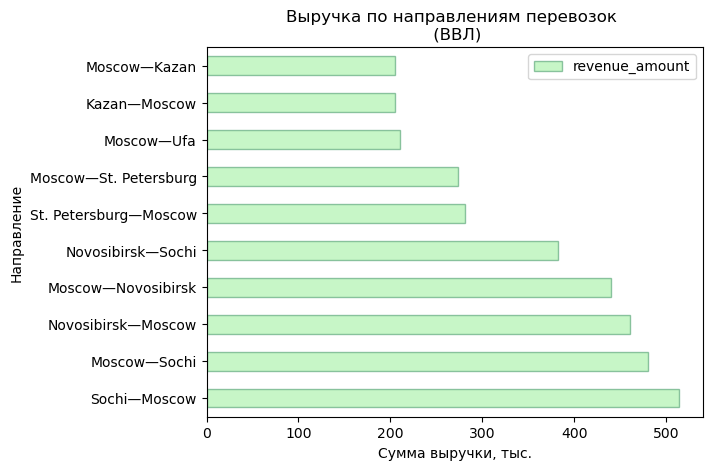

In [271]:
pop_in_rev.plot(kind='barh', x = 'direction', y = 'revenue_amount', color='#90EE90', edgecolor='#2E8B57', alpha=0.5)
plt.title('Выручка по направлениям перевозок \n (ВВЛ)')
plt.xlabel('Сумма выручки, тыс.')
plt.ylabel('Направление')

Рейсы в/из Сочи и Новосибирска приносят максимальную выручку за поездку, что, вероятно, связано со структурой тарифов и длительностью перелёта.

На направлениях Сочи, Новосибирск и Казань с Москвой выручка из этих городов в столицу превышает обратную. Это указывает на более высокий спрос на перелеты в Москву из регионов.

Несмотря на высокий объем перевозок, рейсы с Санкт-Петербургом и Уфой генерируют наименьшую выручку, что может говорить о более низких тарифах или высокой конкуренции на этих направлениях.

In [272]:
# международные перевозки
top_directions_out = pop_10_out['direction']
pop_out_rev = new_air_d.query("route_flight_type == 'МВЛ' and direction in @top_directions_out").groupby('direction')['revenue_amount'].sum().reset_index().sort_values(by='revenue_amount', ascending=False)
pop_out_rev['revenue_amount'] = pop_out_rev['revenue_amount'] / 1000    #в тыс.
pop_out_rev

,direction,revenue_amount
1,Khudzhand—Moscow,95.19
8,Osh—Moscow,80.92
5,Moscow—Osh,68.13
2,Khudzhand—Novosibirsk,57.74
4,Moscow—Khudzhand,57.71
9,Osh—Novosibirsk,56.98
0,Bishkek—Novosibirsk,48.30
7,Novosibirsk—Osh,47.45
6,Novosibirsk—Bishkek,46.98
3,Moscow—Antalya,38.08


Text(0, 0.5, 'Направление')

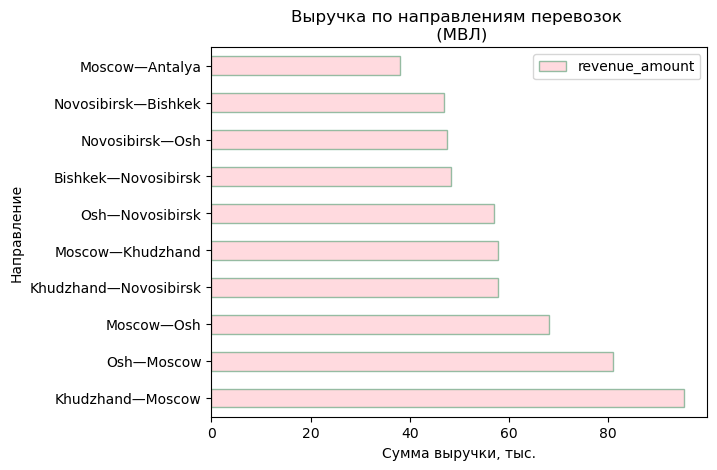

In [273]:
pop_out_rev.plot(kind='barh', x = 'direction', y = 'revenue_amount', color='#FFB6C1', edgecolor='#2E8B57', alpha=0.5)
plt.title('Выручка по направлениям перевозок \n (МВЛ)')
plt.xlabel('Сумма выручки, тыс.')
plt.ylabel('Направление')

Перелеты из Центральной Азии (Ош, Худжанд) в Россию дают максимальную выручку. Направления из России являются, по сути, обратным, **менее доходным потоком**.

Новосибирск — важный узел после Москвы для высокодоходных перелётов с Центральной Азией. Его особенность в достаточно симметричной выручке: рейсы в Новосибирск и из него приносят сопоставимый высокий доход. Это значит, что спрос между ним и городами Киргизии/Таджикистана одинаково платёжеспособен в обе стороны, в отличие от потока в Москву.

Направление в Анталью — низкомаржинальное. 

*<span style="color:#8B0000">3.6 Определите есть ли зависимость выручки от других признаков. Постройте матрицу корреляций.</span>*

Исследуем статистическую зависимость между **выручкой** и **количеством дней до вылета**.

Text(0, 0.5, 'Выручка')

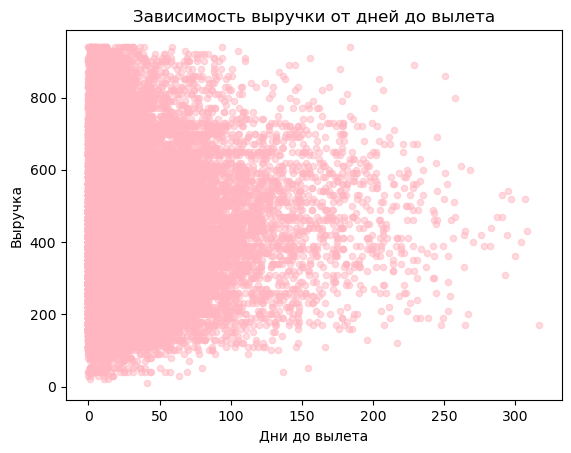

In [274]:
new_air_d.plot(kind='scatter', x='days_before_departure', y='revenue_amount', color='#FFB6C1', alpha=0.5)
plt.title('Зависимость выручки от дней до вылета')
plt.xlabel('Дни до вылета')
plt.ylabel('Выручка')

Выраженной линейной зависимости **почти нет**: облако сильно размыто, особенно при малых днях до вылета. Тем не менее видно, что самые высокие выручки чаще встречаются при бронировании близко к дате вылета, а при раннем бронировании разброс уже меньше и экстремальные значения практически исчезают.

Берем коэффициент корреляции **Спирмена**, поскольку он устойчив к нарушениям нормальности распределения и измеряет монотонную, а не только линейную зависимость, что корректно даже для очищенного от выбросов датасета с правой асимметрией выручки.

<Axes: >

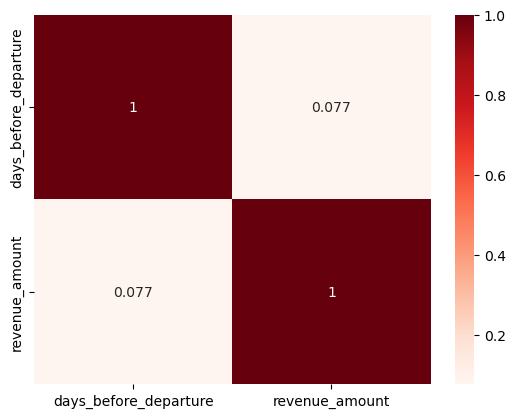

In [275]:
exit_departure = new_air_d[['days_before_departure', 'revenue_amount']].corr(method='spearman')
sns.heatmap(exit_departure, annot=True, cmap='Reds')

Монотонной зависимости практически нет, коэф. корреляции Спирмена незначителен, возможно имеется **нелинейная взаимосвязь**

**Вторая взаимосвязь**. Для переменной **route_flight_type** выполняем бинарное кодирование с помощью словаря, преобразуя категории в дихотомическую числовую переменную, где 0 соответствует внутренним воздушным линиям, а 1 — международным воздушным линиям.

In [276]:
dict_route_flight_type = {'ВВЛ': 0,
                          'МВЛ': 1}

In [277]:
new_air_d['route_flight_type_code'] = new_air_d['route_flight_type'].map(dict_route_flight_type)

То же самое для программы лояльности (выполняем бинарное кодирование).

In [278]:
dict_ffp_flag = {'NO_FFP': 0,
                 'FFP': 1}

In [279]:
new_air_d['ffp_flag_code'] = new_air_d['ffp_flag'].map(dict_ffp_flag)

Продолжаем делать то же самое.

In [280]:
dict_sale_type = {'OFFLINE': 0,
                  'ONLINE': 1}

In [281]:
new_air_d['sale_type_code'] = new_air_d['sale_type'].map(dict_sale_type)

In [282]:
new_air_d.head(2)

,issue_date,flight_date_loc,pax_type,revenue_amount,orig_city_code,dest_city_code,route_flight_type,ffp_flag,sale_type,year,...,days_before_departure,cust_categorization,iata_code_x,departure_city,iata_code_y,destination_city,direction,route_flight_type_code,ffp_flag_code,sale_type_code
0,2021-12-07,2022-01-11,AD,200,MOW,KGD,ВВЛ,NO_FFP,ONLINE,2021,...,35,early_purchase,MOW,Moscow,KGD,Kaliningrad,Moscow—Kaliningrad,0,0,1
1,2021-12-31,2022-01-03,AD,610,UUS,OVB,ВВЛ,NO_FFP,OFFLINE,2021,...,3,late_purchase,UUS,Yuzhno-sakhalinsk,OVB,Novosibirsk,Yuzhno-sakhalinsk—Novosibirsk,0,0,0


В матрице корреляций мы используем **коэффициент корреляции Спирмена**, потому что он является наиболее универсальным и корректным выбором для данных смешанных типов.

Спирмен работает с рангами значений, что позволяет корректно анализировать связи порядковых переменных, для которых Пирсон не предназначен. Для дихотомических переменных, закодированных как 0 и 1, коэффициент Спирмена дает результаты, аналогичные точечно-бисериальной корреляции. При этом Спирмен не требует предположения о линейности связи и нормальности распределения, устойчив к выбросам и корректно измеряет любые монотонные зависимости.

In [283]:
matrix = new_air_d[['route_flight_type_code', 'ffp_flag_code', 'sale_type_code', 'revenue_amount']]

In [284]:
corr_m = matrix.corr(method='spearman')

In [285]:
matrix.corr(method='spearman')

,route_flight_type_code,ffp_flag_code,sale_type_code,revenue_amount
route_flight_type_code,1.000000,-0.160515,-0.105430,0.120561
ffp_flag_code,-0.160515,1.000000,0.321428,-0.055779
sale_type_code,-0.105430,0.321428,1.000000,-0.157606
revenue_amount,0.120561,-0.055779,-0.157606,1.000000


<Axes: >

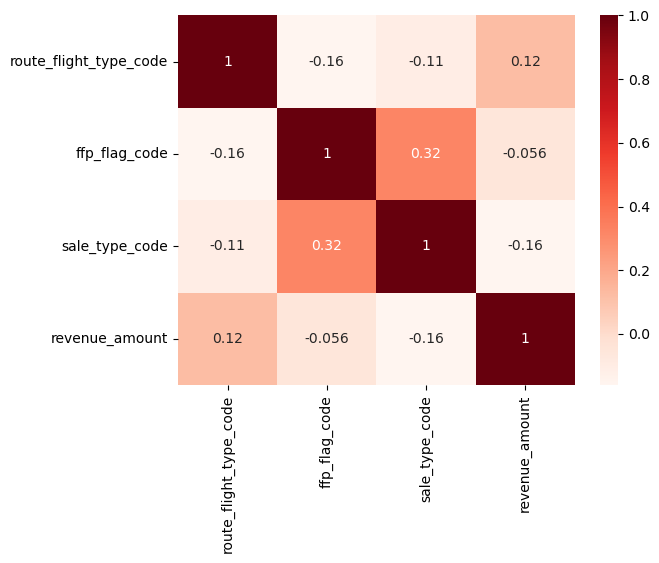

In [286]:
sns.heatmap(corr_m, annot=True, cmap='Reds')

<Axes: xlabel='sale_type_code', ylabel='revenue_amount'>

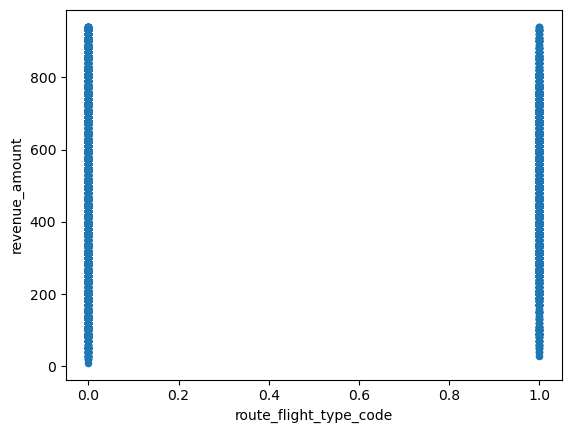

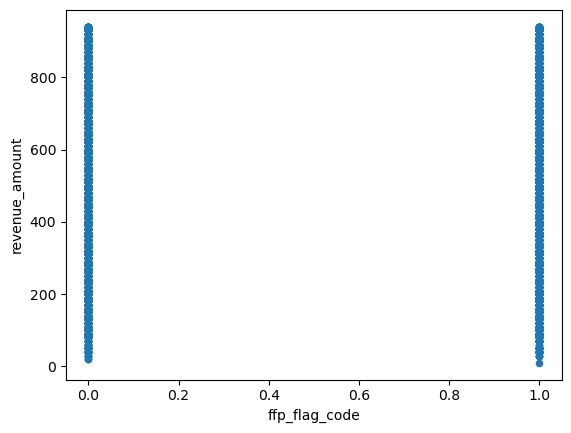

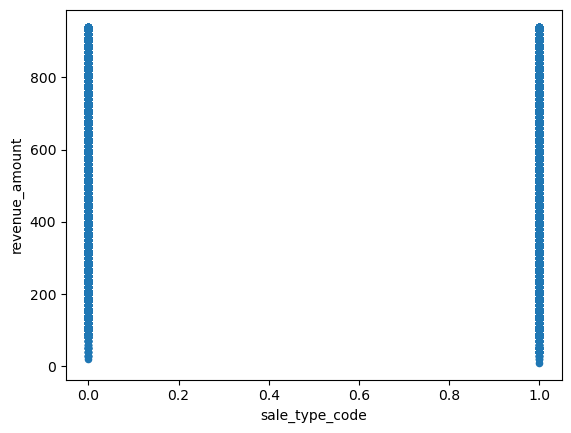

In [287]:
matrix.plot(kind='scatter', x='route_flight_type_code', y='revenue_amount')
matrix.plot(kind='scatter', x='ffp_flag_code', y='revenue_amount')
matrix.plot(kind='scatter', x='sale_type_code', y='revenue_amount')

Корреляционный анализ показал **слабую связь** между категориальными признаками и выручкой. 

Наибольший коэффициент корреляции выявлен между величиной выручки и бинарным признаком типа продажи (-0,16), но даже он указывает на незначительную зависимость. Оффлайн-продажи связаны с более высокой выручкой по сравнению с онлайн-продажами. 

При этом обнаружена умеренная связь (0,32) между статусом программы лояльности и типом продажи, что говорит о взаимосвязанности этих характеристик. Для подтверждения наличия статистической связи между двумя дихотомическими переменными целесообразно использовать коэффициент корреляции **Кендалла**, так как он оптимален для измерения порядковой связи в бинарных данных

Отсутствие сильных линейных корреляций не исключает других форм зависимости, которые могут быть выявлены альтернативными методами анализа.

В целом корреляционный анализ показал, что ни между выручкой и количеством дней до вылета, ни между выручкой и дихотомическими признаками (тип продажи и др.) **<span style="color:#8B0000">статистически значимой монотонной зависимости не выявлено</span>**.

# *<span style="color:#87CEEB">Выводы</span>*

В ходе работы был проведен комплексный анализ данных авиакомпании. На этапе **предобработки** были выполнены основные процедуры, традиционно включаемые в этот этап.

**Исследовательский анализ** включал изучение динамики выручки, где были выявлены сезонные колебания с пиками в определенные периоды. Анализ экстремальных значений позволил идентифицировать аномальные транзакции. При сравнении сезонности продаж статистически значимых различий между осенней и зимней выручкой не выявлено. Исследование паттернов поведения клиентов показало различия в выручке между группами ранних/оптимальных/поздних бронирований.

Определены наиболее популярные направления перелетов, для которых проанализированы показатели выручки. **Корреляционный анализ** выявил слабые связи между выручкой и категориальными признаками, при этом обнаружена умеренная взаимосвязь между статусом программы лояльности и типом продаж.

Полученные результаты предоставляют основу для формирования гипотез о факторах, влияющих на выручку, и могут быть использованы для дальнейшего углубленного анализа и построения прогнозных моделей.